## 1.   Khai báo

In [ ]:
import os, glob, json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

## 2. Cấu hình kịch bản và quản lý thí nghiệm

Toàn bộ kịch bản được điều khiển bằng một từ điển `params`.

Mỗi thí nghiệm tạo một thư mục riêng:

```text
experiments/
└── house_mlp_v1/
    ├── best_model.pt
    ├── params.json
    ├── tuning_results.csv
    └── images/
        ├── figure_001.png
        ├── figure_002.png
        └── ...
```

Trong đó:

- `best_model.pt`: mô hình tốt nhất.
- `params.json`: bản sao đầy đủ của `params` dùng cho thí nghiệm.
- `tuning_results.csv`: kết quả các cấu hình tuning.
- `images/`: lưu hình matplotlib.
- `submission.csv` lưu tại params["experiment"]["submission_dir"]

In [ ]:


params = {

    # --------------------------------------------------------
    # 1. Dữ liệu
    # --------------------------------------------------------
    "data": {
        "input_dir": ".",
        "train_file": "train.csv",
        "test_file": "test.csv",
        "validation_size": 0.30,
        "random_state": 1
    },

    # --------------------------------------------------------
    # 2. Thí nghiệm và nơi lưu kết quả
    # --------------------------------------------------------
    "experiment": {
        "expr_dir": "./experiments",
        "expr_name": "house_mlp_v1",

        # File lưu trong thư mục thí nghiệm
        "best_model_file": "./best_model.pt",
        "params_file": "params.json",

        # Lưu hình phát sinh từ matplotlib
        "save_figures": True,
        "images_dir": "images",
        "figure_dpi": 150,

        # Submission có thể đặt riêng với thư mục thí nghiệm
        # "."               -> thư mục hiện tại
        # "/kaggle/working" -> vị trí thuận tiện trên Kaggle
        "submission_file": "submission.csv",
        "submission_dir": "."
    },

    # --------------------------------------------------------
    # 3. W&B
    # --------------------------------------------------------
    "wandb": {
        "mode": "disabled",   # đổi thành "online" để dùng W&B
        "project": "house-pytorch"
    },

    # --------------------------------------------------------
    # 4. Huấn luyện mặc định
    # --------------------------------------------------------
    "train": {
        "hidden1": 32,
        "hidden2": 16,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 100,
        "weight_decay": 0.0001
    },

   
}

In [ ]:
# ============================================================
# KHỞI TẠO THƯ MỤC VÀ CÁC ARTIFACT CỦA THÍ NGHIỆM
# ============================================================

# Thư mục gốc của thí nghiệm
expr_path = os.path.join(
    params["experiment"]["expr_dir"],
    params["experiment"]["expr_name"]
)
os.makedirs(expr_path, exist_ok=True)

# Các file nằm trực tiếp trong thư mục thí nghiệm
best_model_path = os.path.join(
    expr_path,
    params["experiment"]["best_model_file"]
)

params_path = os.path.join(
    expr_path,
    params["experiment"]["params_file"]
)

# Thư mục chứa ảnh
images_path = os.path.join(
    expr_path,
    params["experiment"]["images_dir"]
)

if params["experiment"]["save_figures"]:
    os.makedirs(images_path, exist_ok=True)

# Submission có thể đặt ở vị trí khác với thư mục thí nghiệm
submission_dir = params["experiment"]["submission_dir"]
os.makedirs(submission_dir, exist_ok=True)

submission_path = os.path.join(
    submission_dir,
    params["experiment"]["submission_file"]
)


# ------------------------------------------------------------
# 1. Dump params xuống JSON
# ------------------------------------------------------------
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(params, f, ensure_ascii=False, indent=4)


# ------------------------------------------------------------
# 2. Tự động lưu mọi matplotlib figure tại thời điểm plt.show()
# ------------------------------------------------------------
import matplotlib.pyplot as plt

# Dùng mẹo kiểm tra xem hàm đã bị ghi đè chưa để tránh lỗi lặp vô tận nếu chạy cell nhiều lần
if not hasattr(plt, '_is_patched'):
    _original_plt_show = plt.show
    _figure_counter = 0

    def show_and_save(*args, **kwargs):
        global _figure_counter

        if params["experiment"]["save_figures"] and plt.get_fignums():
            _figure_counter += 1

            figure_name = f"figure_{_figure_counter:03d}.png"
            figure_path = os.path.join(images_path, figure_name)

            fig = plt.gcf()
            fig.savefig(
                figure_path,
                dpi=params["experiment"]["figure_dpi"],
                bbox_inches="tight"
            )

            print(f"[FIGURE] Đã lưu: {figure_path}")
            
            res = _original_plt_show(*args, **kwargs)
            plt.close(fig) # Xóa hình khỏi bộ nhớ
            return res
        else:
            return _original_plt_show(*args, **kwargs)

    plt.show = show_and_save
    plt._is_patched = True # Đánh dấu khóa là đã sửa hàm

# ------------------------------------------------------------
# Thông tin khởi tạo
# ------------------------------------------------------------
print("=" * 70)
print("BẮT ĐẦU THÍ NGHIỆM")
print("Thời gian        :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("PyTorch          :", torch.__version__)
print("expr_path        :", expr_path)
print("params_path      :", params_path)
print("best_model_path  :", best_model_path)
print("images_path      :", images_path)
print("submission_path  :", submission_path)
print("=" * 70)

print("\nTHAM SỐ HUẤN LUYỆN:")
print(params["train"])



BẮT ĐẦU THÍ NGHIỆM
Thời gian        : 2026-09-26 12:48:56
PyTorch          : 2.14.0+cu130
expr_path        : ./experiments/house_mlp_v1
params_path      : ./experiments/house_mlp_v1/params.json
best_model_path  : ./experiments/house_mlp_v1/./best_model.pt
images_path      : ./experiments/house_mlp_v1/images
submission_path  : ./submission.csv

THAM SỐ HUẤN LUYỆN:
{'hidden1': 32, 'hidden2': 16, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100, 'weight_decay': 0.0001}


## 3. Load data

In [ ]:
input_dir = params["data"]["input_dir"]

train = pd.read_csv(
    os.path.join(input_dir, params["data"]["train_file"])
)

test = pd.read_csv(
    os.path.join(input_dir, params["data"]["test_file"])
)

print("Số dòng train:", train.shape[0], "| Số cột train:", train.shape[1])
print("Số dòng test :", test.shape[0], "| Số cột test :", test.shape[1])

train.head()

Số dòng train: 1460 | Số cột train: 81
Số dòng test : 1459 | Số cột test : 80


### 3.1. Business Understanding

Bộ dữ liệu Ames Housing (Dean De Cock) mô tả gần như mọi khía cạnh của một
căn nhà tại Ames, Iowa, gồm 79 biến giải thích + 1 biến mục tiêu `SalePrice`
(giá bán). Các biến được chia thành 4 nhóm:

- **Continuous (liên tục):** LotArea, GrLivArea, TotalBsmtSF, GarageArea, ...
- **Discrete (rời rạc):** BedroomAbvGr, GarageCars, FullBath, TotRmsAbvGrd, ...
- **Nominal (định danh):** MSZoning, Neighborhood, HouseStyle, SaleType, ...
- **Ordinal (thứ bậc):** ExterQual, KitchenQual, BsmtQual (thang Ex/Gd/TA/Fa/Po), ...

Bước dưới đây chỉ tự động tách theo dtype (numeric vs object) làm điểm khởi
đầu; việc phân đúng vào 4 nhóm ở trên cần đối chiếu thủ công với
`data_description.txt`.

In [ ]:
# Đọc mô tả cột gốc 
with open(os.path.join(input_dir, "data_description.txt"), "r", encoding="utf-8") as f:
    print(f.read()[:2000])   # in trước 2000 ký tự để xem 

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [ ]:
# Tự động group cột theo dtype làm bước khởi đầu
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

# Loại Id và SalePrice ra khỏi danh sách numeric để không lẫn vào feature phân tích
numeric_cols_features = [c for c in numeric_cols if c not in ["Id", "SalePrice"]]

print(f"Số cột numeric (trừ Id, SalePrice): {len(numeric_cols_features)}")
print(numeric_cols_features)

print(f"\nSố cột categorical (object): {len(categorical_cols)}")
print(categorical_cols)

Số cột numeric (trừ Id, SalePrice): 36
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Số cột categorical (object): 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional

## 4. Data Analysis

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Missing values, chỉ hiện cột có thiếu, sắp giảm dần
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Các cột có missing values trong train:")
print(missing)

Các cột có missing values trong train:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_001.png
[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_002.png


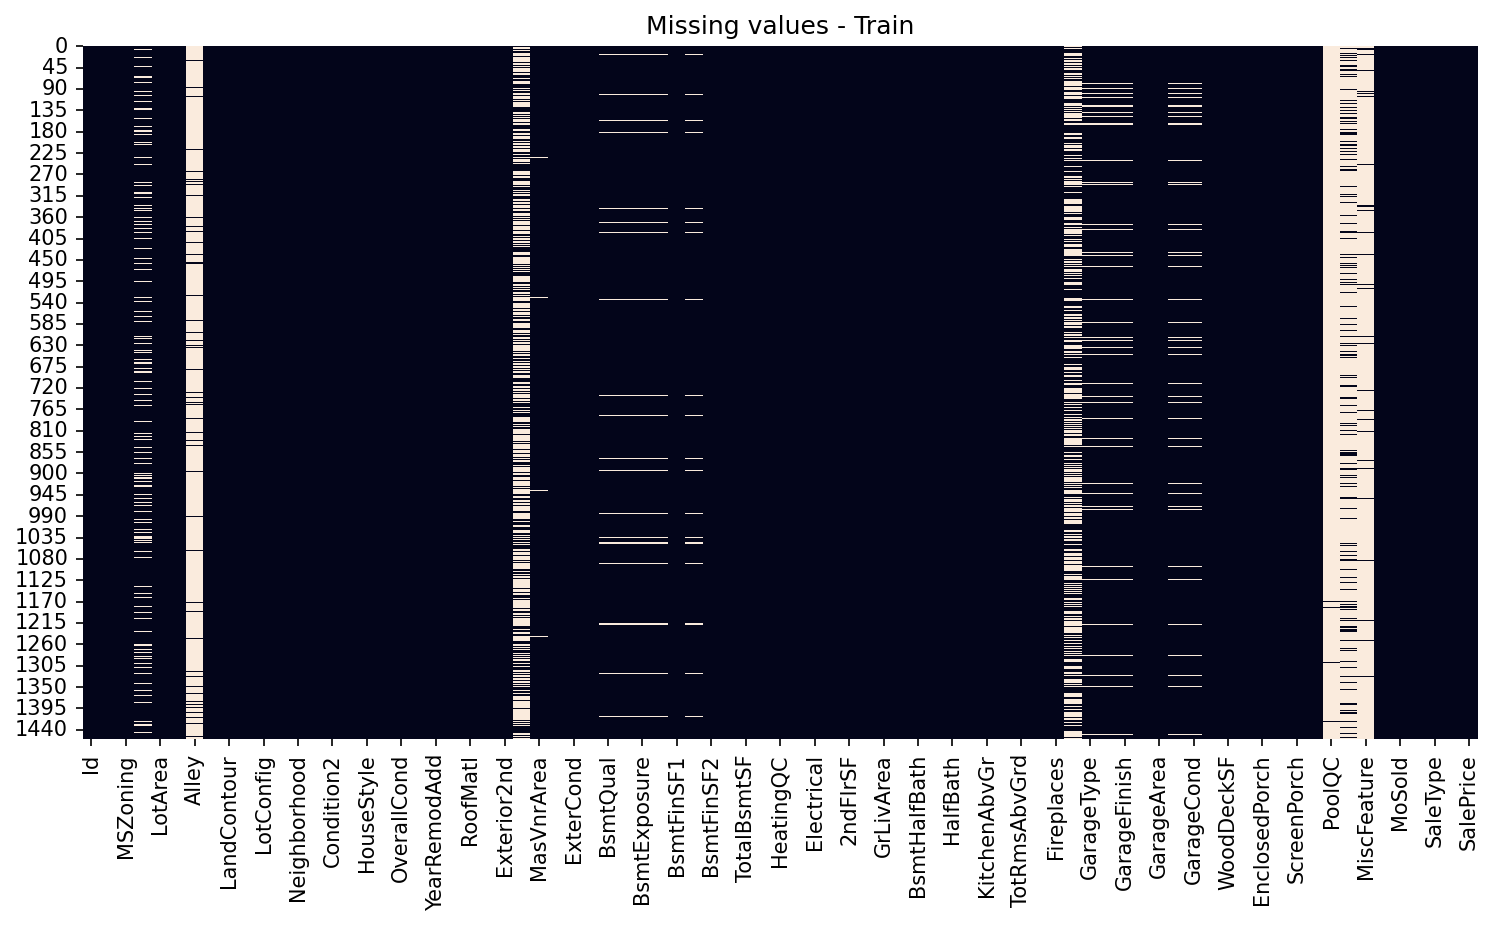

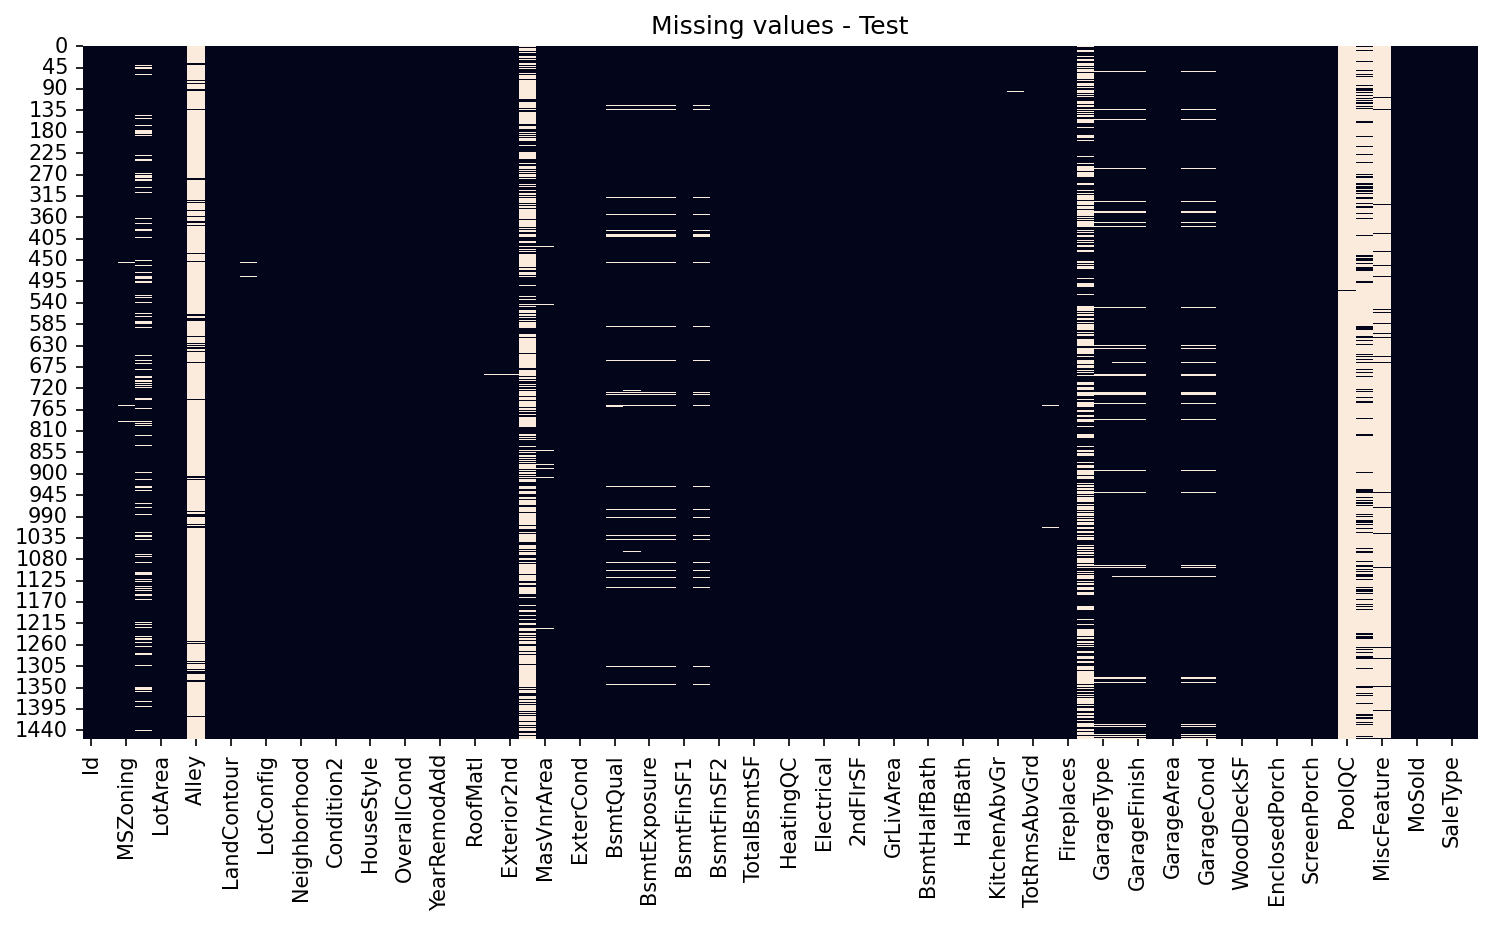

In [ ]:
# Heatmap missing values (plt.show đã được patch để tự lưu ảnh ở section 2)
plt.figure(figsize=(12, 6))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing values - Train")
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(test.isnull(), cbar=False)
plt.title("Missing values - Test")
plt.show()

[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_003.png
Skewness của SalePrice: 1.8828757597682129


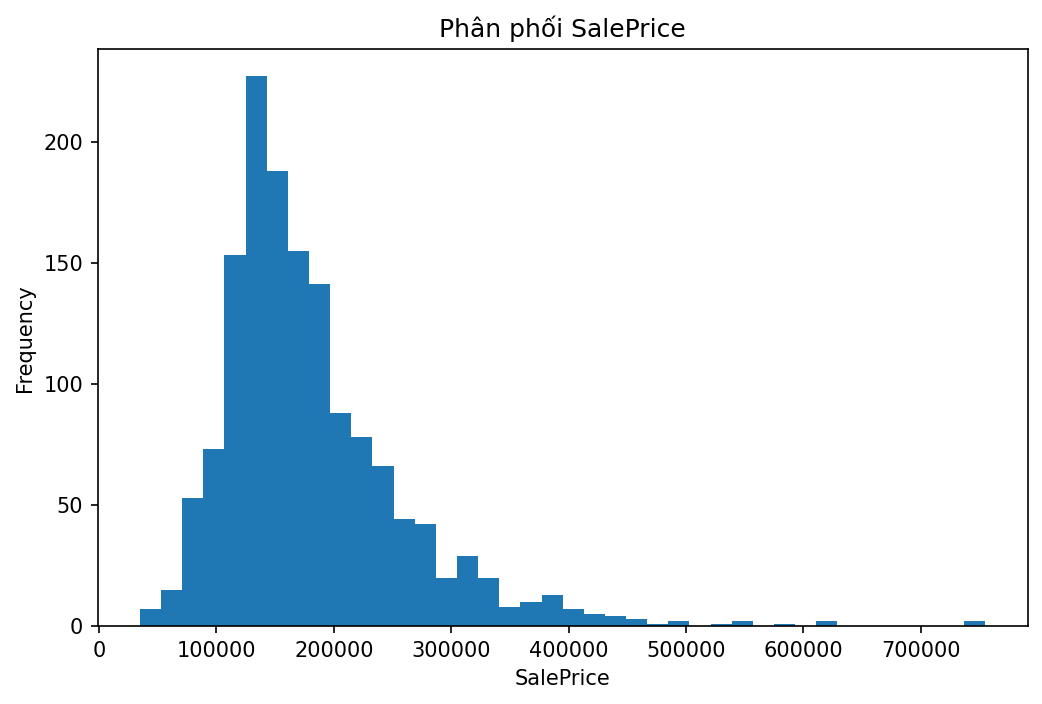

In [ ]:
plt.figure(figsize=(8, 5))
train["SalePrice"].plot(kind="hist", bins=40)
plt.title("Phân phối SalePrice")
plt.xlabel("SalePrice")
plt.show()

print("Skewness của SalePrice:", train["SalePrice"].skew())

[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_004.png


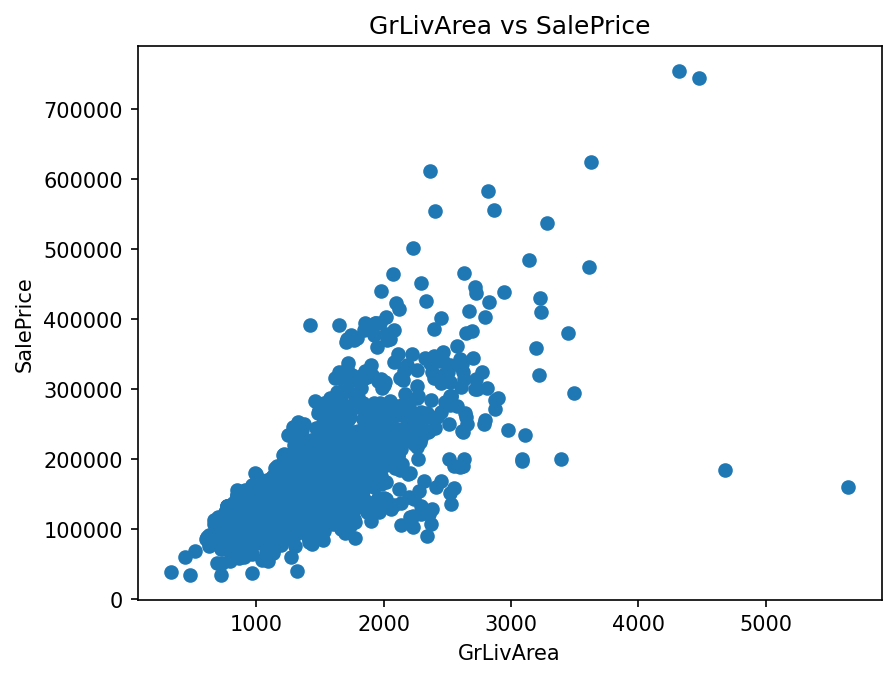

In [ ]:
# Vẽ biểu đồ tương quan giữa diện tích sống (GrLivArea) và giá nhà (SalePrice)
# Để chuẩn bị quan sát outlier > 4000 sqft theo tài liệu
plt.scatter(train["GrLivArea"], train["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

### 4.1. Làm sạch dữ liệu & Xử lý ngoại lệ (Outlier Removal)

Có một số căn nhà có diện tích không gian sống (`GrLivArea`) bất thường lớn hơn 4000 sq ft nhưng lại có giá bán rất thấp so với xu hướng thị trường. Những trường hợp này là ngoại lệ (unusual sales) và không đại diện cho giá nhà thông thường.

- Ta sẽ loại bỏ các dòng có `GrLivArea > 4000` trên tập **train**.
- Ta không xóa bất kỳ dòng nào trên tập **test** 

In [ ]:
# 1. Lưu lại số lượng dòng trước khi xử lý
n_train_before = len(train)

# 2. Xác định các dòng outlier theo khuyến nghị của tác giả Dean De Cock
outliers = train[train["GrLivArea"] > 4000]

# 3. Lọc bỏ các dòng ngoại lệ khỏi tập train
train = train[train["GrLivArea"] <= 4000].reset_index(drop=True)
n_train_after = len(train)
n_removed = n_train_before - n_train_after

# 4. In thông tin chi tiết (Log phục vụ phần báo cáo CRISP-DM)
print("=" * 60)
print("BÁO CÁO XỬ LÝ NGOẠI LỆ (DATA CLEANING LOG)")
print("=" * 60)
print(f"- Điều kiện lọc ngoại lệ : GrLivArea > 4000 sq ft")
print(f"- Số mẫu ban đầu (train) : {n_train_before}")
print(f"- Số mẫu đã loại bỏ     : {n_removed}")
print(f"- Số mẫu còn lại (train) : {n_train_after}")
print(f"- Số mẫu tập test        : {len(test)} (Giữ nguyên)")
print("=" * 60)

BÁO CÁO XỬ LÝ NGOẠI LỆ (DATA CLEANING LOG)
- Điều kiện lọc ngoại lệ : GrLivArea > 4000 sq ft
- Số mẫu ban đầu (train) : 1460
- Số mẫu đã loại bỏ     : 4
- Số mẫu còn lại (train) : 1456
- Số mẫu tập test        : 1459 (Giữ nguyên)


[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_005.png


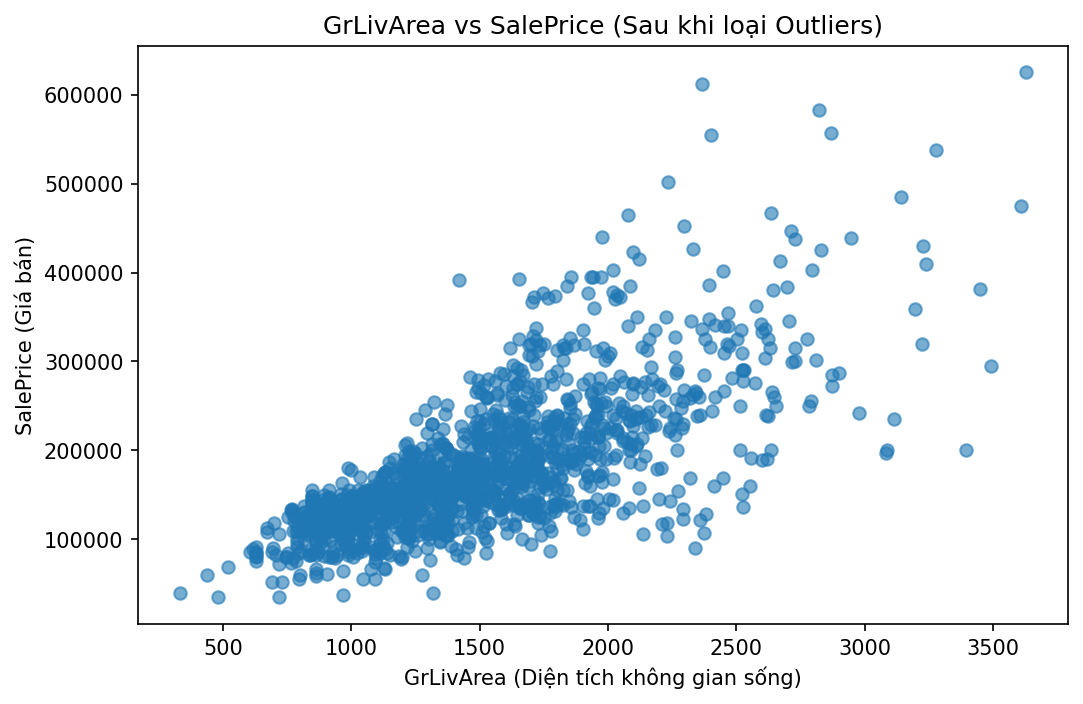

In [ ]:
# Vẽ lại biểu đồ tương quan GrLivArea vs SalePrice sau khi đã loại outlier
plt.figure(figsize=(8, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.6)
plt.title("GrLivArea vs SalePrice (Sau khi loại Outliers)")
plt.xlabel("GrLivArea (Diện tích không gian sống)")
plt.ylabel("SalePrice (Giá bán)")
plt.show()

## 5. Data Preprocessing

Trong bước này, ta tiến hành xử lý tiền xử lý dữ liệu cho bài toán hồi quy giá nhà:
- Gộp tập `train` (bỏ `SalePrice`) và `test` thành `all_data` để đảm bảo khi One-hot encoding không bị lệch cột giữa hai tập.
- Loại bỏ các cột có tỷ lệ giá trị thiếu (missing value) lớn hơn 70%: `Alley`, `PoolQC`, `Fence`, `MiscFeature` cùng với cột `Id`[cite: 1].
- Điền giá trị thiếu (Imputation):
  - Biến số (numerical): điền bằng giá trị trung bình (`mean`)[cite: 1].
  - Biến phân loại (categorical): điền bằng giá trị xuất hiện nhiều nhất (`mode`)[cite: 1].
- Thực hiện One-hot encoding với `pd.get_dummies(..., drop_first=True)`[cite: 1].
- Tách lại thành `X` (train) và `X_test_kaggle` (test) theo đúng số lượng dòng ban đầu.
- Xử lý biến mục tiêu: Chuyển đổi `y = np.log1p(SalePrice)` để giảm độ lệch (skewness) của giá nhà, giúp mô hình hồi quy học tốt hơn.
  

In [ ]:
def preprocess_housing(train_df, test_df):
    # 1. Lưu lại số lượng dòng ban đầu của train để tách sau này
    n_train = len(train_df)
    
    # 2. Tách biến mục tiêu y và gộp train (bỏ SalePrice) với test
    train_features = train_df.drop("SalePrice", axis=1)
    all_data = pd.concat([train_features, test_df], axis=0).reset_index(drop=True)
    
    # 3. Kiểm tra tỷ lệ missing values trước khi bỏ
    print("--- TỶ LỆ MISSING VALUES CÁC CỘT CAO NHẤT ---")
    missing_ratio = (all_data.isnull().sum() / len(all_data)) * 100
    high_missing_cols = missing_ratio[missing_ratio > 70].sort_values(ascending=False)
    print(high_missing_cols)
    
    # 4. Loại bỏ các cột missing > 70% và cột Id
    cols_to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
    all_data = all_data.drop(columns=cols_to_drop)
    print(f"\nĐã loại bỏ các cột: {cols_to_drop}")
    
    # 5. Phân loại các cột số và cột phân loại còn lại
    num_cols = all_data.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = all_data.select_dtypes(include=['object']).columns
    
    # 6. Điền dữ liệu thiếu
    # Điền mean cho cột số
    for col in num_cols:
        if all_data[col].isnull().sum() > 0:
            all_data[col] = all_data[col].fillna(all_data[col].mean())
            
    # Điền mode cho cột phân loại
    for col in cat_cols:
        if all_data[col].isnull().sum() > 0:
            all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
            
    print(f"Tổng số missing value còn lại sau khi điền: {all_data.isnull().sum().sum()}")
    
    # 7. One-hot encoding cho toàn bộ cột dạng chữ/phân loại
    all_data = pd.get_dummies(all_data, drop_first=True)
    
    # 8. Tách lại thành X (train) và X_test_kaggle (test)
    X = all_data.iloc[:n_train, :].copy()
    X_test_kaggle = all_data.iloc[n_train:, :].copy()
    
    # 9. Biến đổi log1p cho biến mục tiêu y (giảm skew)
    y = np.log1p(train_df["SalePrice"]).copy()
    
    return X, y, X_test_kaggle

In [ ]:
# Gọi hàm xử lý dữ liệu
X, y, X_test_kaggle = preprocess_housing(train, test)

# Kiểm tra và xác nhận kích thước của các tập dữ liệu
print("\n" + "=" * 60)
print("KẾT QUẢ TIỀN XỬ LÝ DỮ LIỆU")
print("=" * 60)
print("Shape của X (Train)          :", X.shape)
print("Shape của y (Target Train)   :", y.shape)
print("Shape của X_test_kaggle (Test):", X_test_kaggle.shape)
print("Đồng bộ số lượng cột         :", X.shape[1] == X_test_kaggle.shape[1])
print("=" * 60)

# Hiển thị 5 dòng đầu của X để kiểm tra các cột one-hot encoding
X.head()

--- TỶ LỆ MISSING VALUES CÁC CỘT CAO NHẤT ---
PoolQC         99.725557
MiscFeature    96.397942
Alley          93.207547
Fence          80.445969
dtype: float64

Đã loại bỏ các cột: ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
Tổng số missing value còn lại sau khi điền: 0

KẾT QUẢ TIỀN XỬ LÝ DỮ LIỆU
Shape của X (Train)          : (1456, 234)
Shape của y (Target Train)   : (1456,)
Shape của X_test_kaggle (Test): (1459, 234)
Đồng bộ số lượng cột         : True


### 5.1. Phân chia tập dữ liệu, Chuẩn hóa & Tạo PyTorch Tensors
- Phân chia `X`, `y` thành tập huấn luyện (`X_train`, `y_train`) và tập kiểm định (`X_val`, `y_val`) với tỷ lệ validation lấy từ `params["data"]["validation_size"]`.
- Chuẩn hóa đặc trưng bằng `StandardScaler`: chỉ `fit_transform` trên `X_train`, sau đó áp dụng `transform` cho `X_val` và `X_test_kaggle` để tránh rò rỉ dữ liệu 
- Chuyển đổi dữ liệu sang dạng `torch.Tensor` kiểu `torch.float32`, trong đó nhãn mục tiêu `y` được định hình thành tensor cột `(N, 1)` bằng `.view(-1, 1).
- Đóng gói tập train thành `train_loader` với `TensorDataset` và `DataLoader` để nạp dữ liệu theo mini-batch.

In [ ]:
# 1. Phân chia tập Train và Validation

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=params["data"]["validation_size"],
    random_state=params["data"]["random_state"]
)

# 2. Chuẩn hóa đặc trưng (StandardScaler)
scaler = StandardScaler()

# Chỉ fit trên X_train để tránh rò rỉ dữ liệu
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_kaggle_scaled = scaler.transform(X_test_kaggle)

print("Kích thước sau khi chia tập:")
print(f"- X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"- X_val  : {X_val.shape}, y_val  : {y_val.shape}")

Kích thước sau khi chia tập:
- X_train: (1019, 234), y_train: (1019,)
- X_val  : (437, 234), y_val  : (437,)


In [ ]:
# 3. Chuyển đổi sang PyTorch Tensor (float32)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_kaggle_t = torch.tensor(X_test_kaggle_scaled, dtype=torch.float32)

# 4. Tạo DataLoader cho quá trình huấn luyện
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=params["train"]["batch_size"],
    shuffle=True
)

# 5. Lưu và in thông tin bàn giao cho Member 2 & Member 3
input_size = X_train_t.shape[1]

print("=" * 70)

print("=" * 70)
print(f"- Kích thước Tensor X_train_t  : {X_train_t.shape}")
print(f"- Kích thước Tensor y_train_t  : {y_train_t.shape}")
print(f"- Kích thước Tensor X_val_t    : {X_val_t.shape}")
print(f"- Kích thước Tensor y_val_t    : {y_val_t.shape}")
print(f"- Kích thước Tensor X_kaggle_t : {X_kaggle_t.shape}")
print(f"- Số lượng batch trong train_loader : {len(train_loader)}")
print("-" * 70)
print(f">>> THÔNG SỐ INPUT_SIZE CHO MODEL PYTORCH: {input_size} <<<")
print("-" * 70)
print(f"Danh sách {len(X.columns)} đặc trưng đầu vào (Features):")
print(X.columns.tolist())
print("=" * 70)

- Kích thước Tensor X_train_t  : torch.Size([1019, 234])
- Kích thước Tensor y_train_t  : torch.Size([1019, 1])
- Kích thước Tensor X_val_t    : torch.Size([437, 234])
- Kích thước Tensor y_val_t    : torch.Size([437, 1])
- Kích thước Tensor X_kaggle_t : torch.Size([1459, 234])
- Số lượng batch trong train_loader : 32
----------------------------------------------------------------------
>>> THÔNG SỐ INPUT_SIZE CHO MODEL PYTORCH: 234 <<<
----------------------------------------------------------------------
Danh sách 234 đặc trưng đầu vào (Features):
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 

<cell 4>:69: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) DejaVu Sans Mono.
<cell 4>:69: UserWarning: Glyph 7851 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND TILDE}) missing from font(s) DejaVu Sans Mono.
<cell 4>:69: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) DejaVu Sans Mono.
[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_006.png


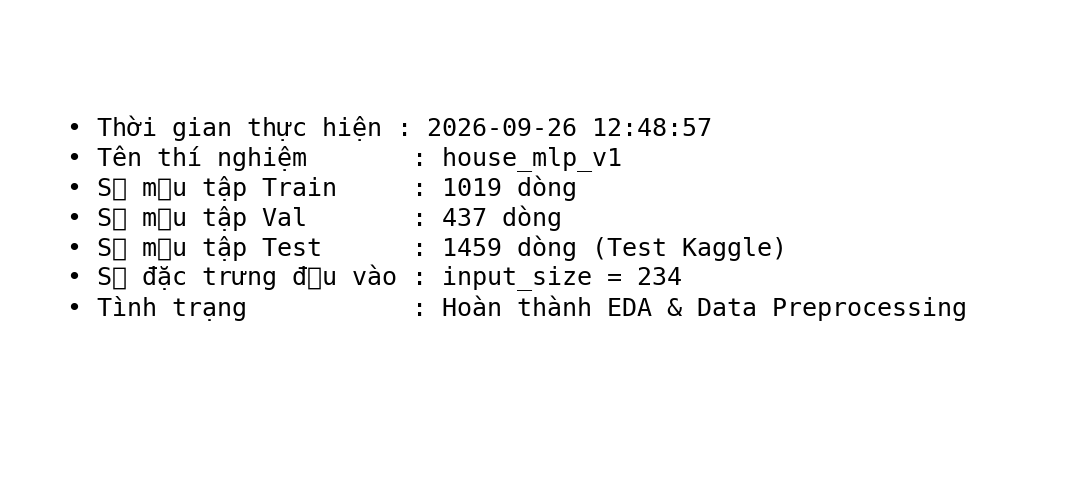

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime

current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


fig, ax = plt.subplots(figsize=(9, 4))
ax.axis("off") # Tắt trục toạ độ để làm dạng bảng thông báo

info_text = (
 
    
    f"• Thời gian thực hiện : {current_time}\n"
    f"• Tên thí nghiệm       : {params['experiment']['expr_name']}\n"
    f"• Số mẫu tập Train     : {X_train_t.shape[0]} dòng\n"
    f"• Số mẫu tập Val       : {X_val_t.shape[0]} dòng\n"
    f"• Số mẫu tập Test      : {X_kaggle_t.shape[0]} dòng (Test Kaggle)\n"
    f"• Số đặc trưng đầu vào : input_size = {input_size}\n"
    f"• Tình trạng           : Hoàn thành EDA & Data Preprocessing\n\n"

    
)

# Chèn chữ vào hình
ax.text(0.05, 0.5, info_text, fontsize=12, family="monospace", va="center")


plt.show()

## 6. Xây dựng Mô hình
Mô hình sử dụng các lớp Linear kết hợp hàm kích hoạt ReLU. Dropout và weight decay được sử dụng như các cơ chế regularization nhằm hạn chế overfitting. Kích thước các hidden layer được điều chỉnh thông qua quá trình tuning.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ================= PHẦN 6: ĐỊNH NGHĨA MÔ HÌNH =================
class HousePriceMLP(nn.Module):
    def __init__(self, input_size, hidden1=64, hidden2=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x)

# Khởi tạo mô hình với input_size từ bước trước
model = HousePriceMLP(
    input_size=input_size,
    hidden1=params["train"]["hidden1"],
    hidden2=params["train"]["hidden2"]
)
print(model)

HousePriceMLP(
  (net): Sequential(
    (0): Linear(in_features=234, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 7. Huấn luyện, Fit Mô hình

In [ ]:
# ================= PHẦN 7: HUẤN LUYỆN =================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=params["train"]["batch_size"],
    shuffle=True
)

model = HousePriceMLP(
    input_size=input_size,
    hidden1=params["train"]["hidden1"],
    hidden2=params["train"]["hidden2"],
    dropout=0.2
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=params["train"]["learning_rate"],
    weight_decay=params["train"]["weight_decay"]
)

epochs = params["train"]["epochs"]

train_losses = []
val_losses = []

best_val_loss = float("inf")

print("--- BẮT ĐẦU HUẤN LUYỆN ---")

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()

    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()

    val_losses.append(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            f"  -> Lưu model tốt nhất tại epoch {epoch + 1}, "
            f"Val Loss = {val_loss:.6f}"
        )

    if (epoch + 1) % 15 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}"
        )

--- BẮT ĐẦU HUẤN LUYỆN ---
  -> Lưu model tốt nhất tại epoch 1, Val Loss = 128.194504
  -> Lưu model tốt nhất tại epoch 2, Val Loss = 83.241440
  -> Lưu model tốt nhất tại epoch 3, Val Loss = 24.376463
  -> Lưu model tốt nhất tại epoch 4, Val Loss = 7.239992
  -> Lưu model tốt nhất tại epoch 5, Val Loss = 5.112516
  -> Lưu model tốt nhất tại epoch 6, Val Loss = 4.359141
  -> Lưu model tốt nhất tại epoch 7, Val Loss = 3.916014
  -> Lưu model tốt nhất tại epoch 8, Val Loss = 3.430589
  -> Lưu model tốt nhất tại epoch 9, Val Loss = 3.173114
  -> Lưu model tốt nhất tại epoch 10, Val Loss = 3.090941
  -> Lưu model tốt nhất tại epoch 11, Val Loss = 2.797225
  -> Lưu model tốt nhất tại epoch 12, Val Loss = 2.730388
  -> Lưu model tốt nhất tại epoch 13, Val Loss = 2.679049
  -> Lưu model tốt nhất tại epoch 14, Val Loss = 2.597418
  -> Lưu model tốt nhất tại epoch 15, Val Loss = 2.553395
Epoch [15/100], Train Loss: 3.3190, Val Loss: 2.5534
  -> Lưu model tốt nhất tại epoch 16, Val Loss = 2.4409

## 8. Đánh giá Mô hình
Sử dụng kỹ thuật đảo ngược logarit (`np.expm1`) để chuyển giá trị đánh giá về lại đơn vị tiền tệ thực tế (Đô-la).

--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP VALIDATION ---
Validation RMSE (Kaggle metric): 1.0887
Validation MAE (USD):            $101,171.77
Validation R2 (log1p):            -5.8515
[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_007.png


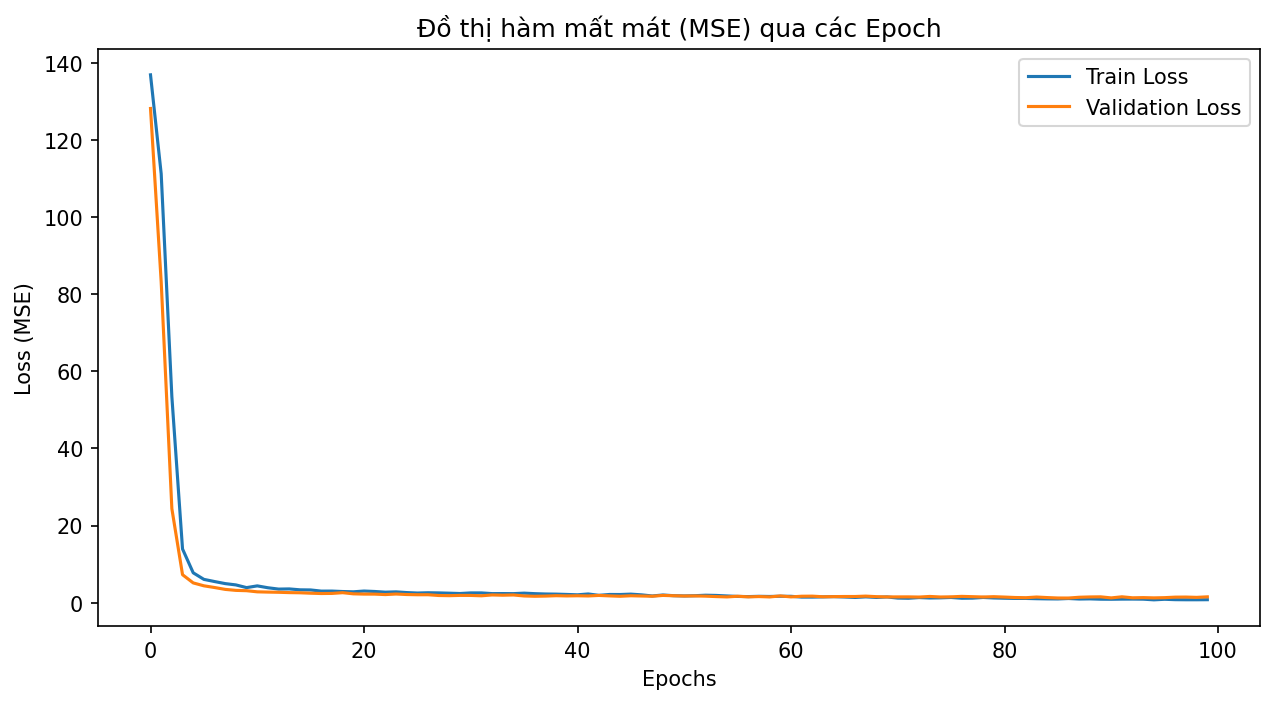

In [ ]:
# ================= PHẦN 8: ĐÁNH GIÁ MÔ HÌNH =================
model.load_state_dict(
    torch.load(best_model_path)
)

model.eval()
with torch.no_grad():
    # 1. Lấy giá trị logarit gốc do mô hình xuất ra
    y_val_pred_log = model(X_val_t).numpy()
    y_val_true_log = y_val_t.numpy()
    
    # 2. Sử dụng expm1 để đưa về giá tiền thật (chỉ dùng để xem MAE)
    y_val_pred_dollar = np.expm1(y_val_pred_log)
    y_val_true_dollar = np.expm1(y_val_true_log)

# Tính RMSE và R2 trên thang đo Logarit
mse = mean_squared_error(y_val_true_log, y_val_pred_log)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_true_log, y_val_pred_log)

# Tính MAE trên tiền thực tế
mae = mean_absolute_error(y_val_true_dollar, y_val_pred_dollar)

print("--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP VALIDATION ---")
print(f"Validation RMSE (Kaggle metric): {rmse:.4f}")
print(f"Validation MAE (USD):            ${mae:,.2f}")
print(f"Validation R2 (log1p):            {r2:.4f}")

# Vẽ đồ thị Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Đồ thị hàm mất mát (MSE) qua các Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# PHẦN 9: TUNING

## 9.1. Tuning với MLP

In [ ]:
# ================= 9.1 TUNING =================

def run_experiment(config):

    torch.manual_seed(42)
    np.random.seed(42)

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=config["batch_size"],
        shuffle=True
    )

    model = HousePriceMLP(
        input_size=input_size,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    best_val_loss = float("inf")
    best_state = None

    for epoch in range(config["epochs"]):

        model.train()

        for X_batch, y_batch in loader:

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():
            val_preds = model(X_val_t)

            val_loss = criterion(
                val_preds,
                y_val_t
            ).item()

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    # Khôi phục đúng checkpoint tốt nhất
    model.load_state_dict(best_state)

    val_rmse = np.sqrt(best_val_loss)

    return val_rmse, model

In [ ]:
tuning_configs = [
    {
        "hidden1": 24,
        "hidden2": 12,
        "learning_rate": 0.00375,
        "weight_decay": 0.005,
        "batch_size": 32,
        "epochs": 125,
        "dropout": 0.15
    },
    {
        "hidden1": 24,
        "hidden2": 12,
        "learning_rate": 0.00375,
        "weight_decay": 0.005,
        "batch_size": 32,
        "epochs": 125,
        "dropout": 0.20
    },
    {
        "hidden1": 24,
        "hidden2": 12,
        "learning_rate": 0.00375,
        "weight_decay": 0.005,
        "batch_size": 32,
        "epochs": 125,
        "dropout": 0.25
    },
    {
        "hidden1": 24,
        "hidden2": 12,
        "learning_rate": 0.00375,
        "weight_decay": 0.005,
        "batch_size": 32,
        "epochs": 125,
        "dropout": 0.30
    }
]

In [ ]:
tuning_results = []

best_tuned_rmse = float("inf")
best_tuned_model = None
best_tuned_config = None

for i, config in enumerate(tuning_configs):

    print("\n" + "=" * 60)
    print(f"THÍ NGHIỆM {i + 1}")
    print(config)
    print("=" * 60)

    rmse, tuned_model = run_experiment(config)

    tuning_results.append({
        "experiment": i + 1,
        "hidden1": config["hidden1"],
        "hidden2": config["hidden2"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "dropout": config["dropout"],
        "val_rmse": rmse
    })

    print(f"Validation RMSE: {rmse:.4f}")

    # Giữ lại model tốt nhất
    if rmse < best_tuned_rmse:

        best_tuned_rmse = rmse

        best_tuned_model = tuned_model

        best_tuned_config = config.copy()


tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="val_rmse",
    ascending=True
).reset_index(drop=True)

print("\nKẾT QUẢ TUNING:")
display(tuning_results_df)


THÍ NGHIỆM 1
{'hidden1': 24, 'hidden2': 12, 'learning_rate': 0.00375, 'weight_decay': 0.005, 'batch_size': 32, 'epochs': 125, 'dropout': 0.15}
Validation RMSE: 0.1322

THÍ NGHIỆM 2
{'hidden1': 24, 'hidden2': 12, 'learning_rate': 0.00375, 'weight_decay': 0.005, 'batch_size': 32, 'epochs': 125, 'dropout': 0.2}
Validation RMSE: 0.1309

THÍ NGHIỆM 3
{'hidden1': 24, 'hidden2': 12, 'learning_rate': 0.00375, 'weight_decay': 0.005, 'batch_size': 32, 'epochs': 125, 'dropout': 0.25}
Validation RMSE: 0.1333

THÍ NGHIỆM 4
{'hidden1': 24, 'hidden2': 12, 'learning_rate': 0.00375, 'weight_decay': 0.005, 'batch_size': 32, 'epochs': 125, 'dropout': 0.3}
Validation RMSE: 0.1347

KẾT QUẢ TUNING:
   experiment  hidden1  hidden2  learning_rate  weight_decay  batch_size  epochs  dropout  val_rmse
0           2       24       12        0.00375         0.005          32     125     0.20  0.130914
1           1       24       12        0.00375         0.005          32     125     0.15  0.132151
2           3

In [ ]:
best_tuned_model_path = os.path.join(
    expr_path,
    "best_tuned_model.pt"
)

torch.save(
    best_tuned_model.state_dict(),
    best_tuned_model_path
)

print(f"\nĐã lưu best tuned model tại:")
print(best_tuned_model_path)


Đã lưu best tuned model tại:
./experiments/house_mlp_v1/best_tuned_model.pt


In [ ]:
# ================= LƯU KẾT QUẢ TUNING =================

tuning_results_path = os.path.join(
    expr_path,
    "tuning_results.csv"
)

tuning_results_df.to_csv(
    tuning_results_path,
    index=False
)

print(f"Đã lưu tuning results tại:")
print(tuning_results_path)

Đã lưu tuning results tại:
./experiments/house_mlp_v1/tuning_results.csv


[FIGURE] Đã lưu: ./experiments/house_mlp_v1/images/figure_008.png


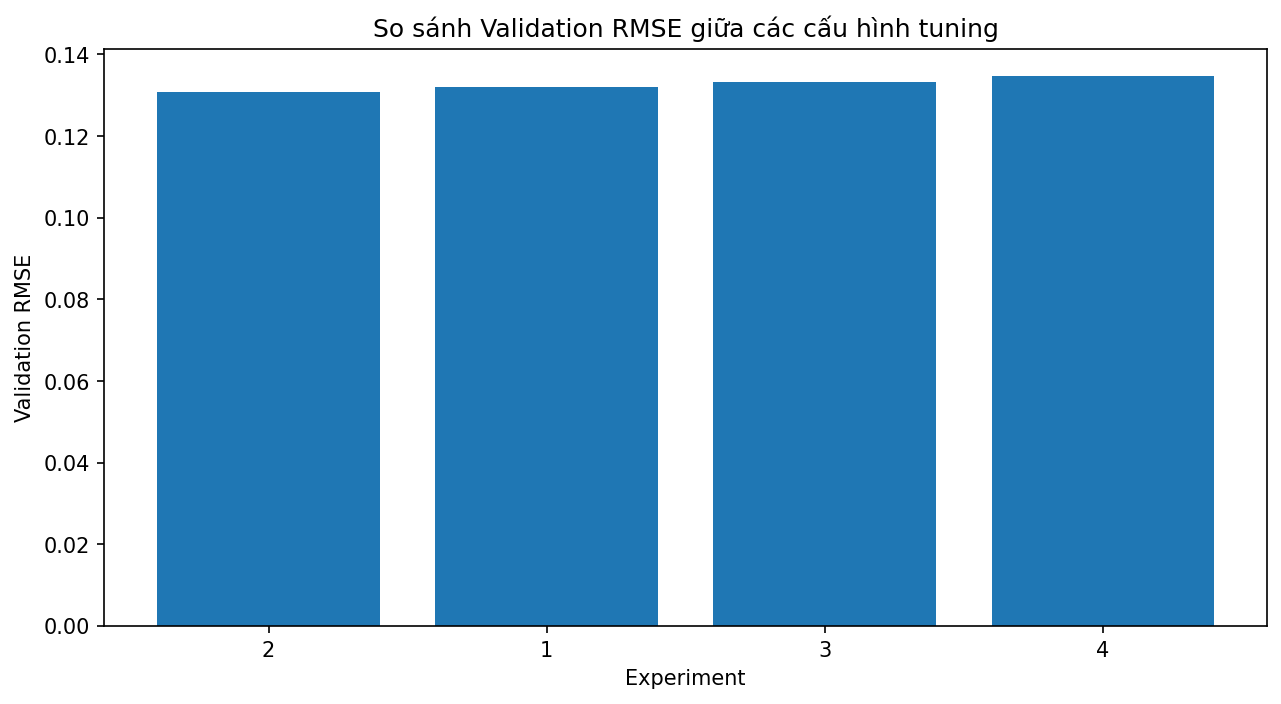

In [ ]:
# ================= BIỂU ĐỒ KẾT QUẢ TUNING =================

plt.figure(figsize=(10, 5))

plt.bar(
    tuning_results_df["experiment"].astype(str),
    tuning_results_df["val_rmse"]
)

plt.xlabel("Experiment")
plt.ylabel("Validation RMSE")
plt.title("So sánh Validation RMSE giữa các cấu hình tuning")

plt.show()

In [ ]:
# ================= CHỐT KẾT QUẢ TUNING =================

best_row = tuning_results_df.iloc[0]

best_config = {
    "hidden1": int(best_row["hidden1"]),
    "hidden2": int(best_row["hidden2"]),
    "learning_rate": float(best_row["learning_rate"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
    "dropout": float(best_row["dropout"])
}

best_val_rmse = float(best_row["val_rmse"])

print("=" * 60)
print("CẤU HÌNH TỐT NHẤT SAU TUNING")
print("=" * 60)

for key, value in best_config.items():
    print(f"{key:<15}: {value}")

print("-" * 60)
print(f"Best Validation RMSE: {best_val_rmse:.4f}")
print("=" * 60)

print("\nBest tuned model:")
print(best_tuned_model_path)

print("\nTuning results:")
print(tuning_results_path)

CẤU HÌNH TỐT NHẤT SAU TUNING
hidden1        : 24
hidden2        : 12
learning_rate  : 0.00375
weight_decay   : 0.005
batch_size     : 32
epochs         : 125
dropout        : 0.2
------------------------------------------------------------
Best Validation RMSE: 0.1309

Best tuned model:
./experiments/house_mlp_v1/best_tuned_model.pt

Tuning results:
./experiments/house_mlp_v1/tuning_results.csv


## 9.2. Thêm XGBoost

In [ ]:
# ================= XGBOOST TUNING =================
from xgboost import XGBRegressor

xgb_configs = [
    {
        "max_depth": 2,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 4,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 3,
        "min_child_weight": 3,
        "learning_rate": 0.02,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 3,
        "min_child_weight": 5,
        "learning_rate": 0.02,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.01,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

xgb_results = []

for i, config in enumerate(xgb_configs):

    print("=" * 60)
    print(f"XGBoost Experiment {i + 1}")
    print(config)

    model_xgb = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=3000,
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        min_child_weight=config["min_child_weight"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        eval_metric="rmse",
        early_stopping_rounds=100
    )

    model_xgb.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    pred = model_xgb.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )

    xgb_results.append({
        "experiment": i + 1,
        **config,
        "best_iteration": model_xgb.best_iteration,
        "val_rmse": rmse,
        "model": model_xgb
    })

    print(f"Best iteration : {model_xgb.best_iteration}")
    print(f"Validation RMSE: {rmse:.4f}")

XGBoost Experiment 1
{'max_depth': 2, 'min_child_weight': 1, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iteration : 1078
Validation RMSE: 0.1255
XGBoost Experiment 2
{'max_depth': 3, 'min_child_weight': 1, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iteration : 781
Validation RMSE: 0.1255
XGBoost Experiment 3
{'max_depth': 4, 'min_child_weight': 1, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iteration : 586
Validation RMSE: 0.1275
XGBoost Experiment 4
{'max_depth': 3, 'min_child_weight': 3, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iteration : 785
Validation RMSE: 0.1255
XGBoost Experiment 5
{'max_depth': 3, 'min_child_weight': 5, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iteration : 867
Validation RMSE: 0.1259
XGBoost Experiment 6
{'max_depth': 3, 'min_child_weight': 1, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iterati

In [ ]:
# ================= CHUẨN BỊ BEST MLP + BEST XGBOOST =================

# 1. Lấy prediction của MLP tốt nhất trên validation
best_tuned_model.eval()

with torch.no_grad():
    mlp_val_pred = (
        best_tuned_model(X_val_t)
        .numpy()
        .reshape(-1)
    )

# 2. Tìm XGBoost tốt nhất từ xgb_results
xgb_results_df = pd.DataFrame(
    xgb_results
).sort_values(
    by="val_rmse",
    ascending=True
).reset_index(drop=True)

best_xgb_row = xgb_results_df.iloc[0]

# 3. Lấy đúng model XGBoost tốt nhất
best_xgb_model = xgb_results[
    int(best_xgb_row["experiment"]) - 1
]["model"]

# 4. Prediction trên validation
best_xgb_val_pred = best_xgb_model.predict(
    X_val
)

# 5. In kiểm tra
mlp_check_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        mlp_val_pred
    )
)

xgb_check_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_xgb_val_pred
    )
)

print("=" * 60)
print("BEST MODELS READY FOR ENSEMBLE")
print("=" * 60)
print(f"MLP RMSE : {mlp_check_rmse:.6f}")
print(f"XGB RMSE : {xgb_check_rmse:.6f}")
print(
    f"XGB best iteration: "
    f"{int(best_xgb_row['best_iteration'])}"
)
print("=" * 60)

BEST MODELS READY FOR ENSEMBLE
MLP RMSE : 0.130914
XGB RMSE : 0.124530
XGB best iteration: 1696


In [ ]:
# ================= RE-BLEND BEST MLP + BEST XGBOOST =================

blend_results = []

for w_mlp in np.arange(0.0, 1.01, 0.01):

    w_xgb = 1.0 - w_mlp

    pred = (
        w_mlp * mlp_val_pred
        + w_xgb * best_xgb_val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )

    blend_results.append({
        "mlp_weight": round(w_mlp, 2),
        "xgb_weight": round(w_xgb, 2),
        "val_rmse": rmse
    })

blend_df = pd.DataFrame(blend_results).sort_values(
    "val_rmse"
).reset_index(drop=True)

best_blend = blend_df.iloc[0]

print("=" * 60)
print("BEST MLP + XGBOOST")
print("=" * 60)
print(f"MLP weight : {best_blend['mlp_weight']:.2f}")
print(f"XGB weight : {best_blend['xgb_weight']:.2f}")
print(f"RMSE       : {best_blend['val_rmse']:.4f}")
print("=" * 60)

BEST MLP + XGBOOST
MLP weight : 0.39
XGB weight : 0.61
RMSE       : 0.1199


### Tuning XGBOOST Model

In [ ]:
# ================= XGBOOST FINE-TUNING =================

xgb_fine_configs = [

    # Baseline tốt nhất hiện tại
    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0
    },

    # Thay đổi min_child_weight
    {
        "max_depth": 3,
        "min_child_weight": 3,
        "learning_rate": 0.02,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0
    },

    {
        "max_depth": 3,
        "min_child_weight": 5,
        "learning_rate": 0.02,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0
    },

    # Subsample
    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.70,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0
    },

    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.90,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0
    },

    # Column sampling
    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.80,
        "colsample_bytree": 0.70,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0
    },

    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.80,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0
    },

    # Regularization
    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.01,
        "reg_lambda": 1.0
    },

    {
        "max_depth": 3,
        "min_child_weight": 1,
        "learning_rate": 0.02,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 2.0
    }
]

xgb_fine_results = []

for i, config in enumerate(xgb_fine_configs):

    print("\n" + "=" * 60)
    print(f"XGBOOST FINE-TUNE {i + 1}")
    print(config)
    print("=" * 60)

    model_xgb = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=4000,
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        min_child_weight=config["min_child_weight"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        reg_alpha=config["reg_alpha"],
        reg_lambda=config["reg_lambda"],
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        eval_metric="rmse",
        early_stopping_rounds=120
    )

    model_xgb.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    pred = model_xgb.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    xgb_fine_results.append({
        "experiment": i + 1,
        **config,
        "best_iteration": model_xgb.best_iteration,
        "val_rmse": rmse,
        "model": model_xgb
    })

    print(f"Best iteration : {model_xgb.best_iteration}")
    print(f"Validation RMSE: {rmse:.4f}")


XGBOOST FINE-TUNE 1
{'max_depth': 3, 'min_child_weight': 1, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
Best iteration : 781
Validation RMSE: 0.1255

XGBOOST FINE-TUNE 2
{'max_depth': 3, 'min_child_weight': 3, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
Best iteration : 785
Validation RMSE: 0.1255

XGBOOST FINE-TUNE 3
{'max_depth': 3, 'min_child_weight': 5, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
Best iteration : 867
Validation RMSE: 0.1259

XGBOOST FINE-TUNE 4
{'max_depth': 3, 'min_child_weight': 1, 'learning_rate': 0.02, 'subsample': 0.7, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
Best iteration : 877
Validation RMSE: 0.1230

XGBOOST FINE-TUNE 5
{'max_depth': 3, 'min_child_weight': 1, 'learning_rate': 0.02, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}


In [ ]:
# ================= BEST XGBOOST FINE-TUNED =================

xgb_fine_df = pd.DataFrame(xgb_fine_results)

xgb_fine_df = xgb_fine_df.sort_values(
    by="val_rmse"
).reset_index(drop=True)

display(
    xgb_fine_df[
        [
            "experiment",
            "max_depth",
            "min_child_weight",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "reg_alpha",
            "reg_lambda",
            "best_iteration",
            "val_rmse"
        ]
    ]
)

best_xgb_fine_row = xgb_fine_df.iloc[0]

best_xgb_fine_model = xgb_fine_results[
    int(best_xgb_fine_row["experiment"]) - 1
]["model"]

best_xgb_fine_val_pred = best_xgb_fine_model.predict(X_val)

print("=" * 60)
print("BEST XGBOOST FINE-TUNED")
print("=" * 60)
print(f"Validation RMSE: {best_xgb_fine_row['val_rmse']:.4f}")
print(f"Best iteration : {int(best_xgb_fine_row['best_iteration'])}")
print("=" * 60)

   experiment  max_depth  min_child_weight  learning_rate  subsample  colsample_bytree  reg_alpha  reg_lambda  best_iteration  val_rmse
0           4          3                 1           0.02        0.7               0.8       0.00         1.0             877  0.122968
1           6          3                 1           0.02        0.8               0.7       0.00         1.0            1009  0.123815
2           9          3                 1           0.02        0.8               0.8       0.00         2.0             847  0.124506
3           5          3                 1           0.02        0.9               0.8       0.00         1.0            1004  0.124963
4           2          3                 3           0.02        0.8               0.8       0.00         1.0             785  0.125511
5           1          3                 1           0.02        0.8               0.8       0.00         1.0             781  0.125539
6           8          3                 1      

In [ ]:
# ================= RE-BLEND MLP + FINE-TUNED XGBOOST =================

fine_blend_results = []

for w_mlp in np.arange(0.0, 1.01, 0.01):

    w_xgb = 1.0 - w_mlp

    pred = (
        w_mlp * mlp_val_pred
        + w_xgb * best_xgb_fine_val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    fine_blend_results.append({
        "mlp_weight": round(w_mlp, 2),
        "xgb_weight": round(w_xgb, 2),
        "val_rmse": rmse
    })

fine_blend_df = pd.DataFrame(
    fine_blend_results
).sort_values(
    by="val_rmse"
).reset_index(drop=True)

best_fine_blend = fine_blend_df.iloc[0]

print("=" * 60)
print("BEST MLP + FINE-TUNED XGBOOST")
print("=" * 60)
print(f"MLP weight : {best_fine_blend['mlp_weight']:.2f}")
print(f"XGB weight : {best_fine_blend['xgb_weight']:.2f}")
print(f"RMSE       : {best_fine_blend['val_rmse']:.4f}")
print("=" * 60)

display(fine_blend_df.head(10))

BEST MLP + FINE-TUNED XGBOOST
MLP weight : 0.36
XGB weight : 0.64
RMSE       : 0.1191
   mlp_weight  xgb_weight  val_rmse
0        0.36        0.64  0.119116
1        0.35        0.65  0.119119
2        0.37        0.63  0.119119
3        0.34        0.66  0.119128
4        0.38        0.62  0.119128
5        0.33        0.67  0.119143
6        0.39        0.61  0.119143
7        0.32        0.68  0.119164
8        0.40        0.60  0.119164
9        0.31        0.69  0.119191


In [ ]:
# ================= REFINE CHAMPION BLEND =================

champion_blend_results = []

for w_mlp in np.arange(0.34, 0.43, 0.001):

    w_xgb = 1.0 - w_mlp

    pred = (
        w_mlp * mlp_val_pred
        + w_xgb * best_xgb_val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    champion_blend_results.append({
        "mlp_weight": w_mlp,
        "xgb_weight": w_xgb,
        "val_rmse": rmse
    })

champion_blend_df = pd.DataFrame(
    champion_blend_results
).sort_values(
    "val_rmse"
).reset_index(drop=True)

best_champion_blend = champion_blend_df.iloc[0]

print("=" * 60)
print("REFINED CHAMPION BLEND")
print("=" * 60)
print(f"MLP weight : {best_champion_blend['mlp_weight']:.3f}")
print(f"XGB weight : {best_champion_blend['xgb_weight']:.3f}")
print(f"RMSE       : {best_champion_blend['val_rmse']:.6f}")
print("=" * 60)

display(champion_blend_df.head(10))

REFINED CHAMPION BLEND
MLP weight : 0.390
XGB weight : 0.610
RMSE       : 0.119927
   mlp_weight  xgb_weight  val_rmse
0       0.390       0.610  0.119927
1       0.389       0.611  0.119928
2       0.391       0.609  0.119928
3       0.388       0.612  0.119928
4       0.392       0.608  0.119928
5       0.387       0.613  0.119928
6       0.393       0.607  0.119928
7       0.386       0.614  0.119928
8       0.394       0.606  0.119928
9       0.385       0.615  0.119928


### Lưu Champion Baseline

In [ ]:
# ================= CHAMPION BASELINE =================
champion_mlp_weight = 0.38
champion_xgb_weight = 0.62
champion_pred = (
    champion_mlp_weight * mlp_val_pred
    + champion_xgb_weight * best_xgb_val_pred
)
champion_rmse = np.sqrt(mean_squared_error(y_val, champion_pred))

print("=" * 60)
print("CURRENT CHAMPION")
print("=" * 60)
print(f"MLP weight : {champion_mlp_weight:.3f}")
print(f"XGB weight : {champion_xgb_weight:.3f}")
print(f"RMSE       : {champion_rmse:.6f}")
print("=" * 60)

CURRENT CHAMPION
MLP weight : 0.380
XGB weight : 0.620
RMSE       : 0.119930


### Thêm Model CatBoost

In [ ]:
# ================= CATBOOST BASELINE =================

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3.0,
    random_strength=1.0,
    random_seed=42,
    verbose=False,
    thread_count=-1
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    verbose=False
)

cat_val_pred = cat_model.predict(X_val)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        cat_val_pred
    )
)

print("=" * 60)
print("CATBOOST VALIDATION")
print("=" * 60)
print(f"Best iteration : {cat_model.get_best_iteration()}")
print(f"Validation RMSE: {cat_rmse:.4f}")
print("=" * 60)

CATBOOST VALIDATION
Best iteration : 986
Validation RMSE: 0.1242


In [ ]:
# ================= ENSEMBLE 3 MODELS =================

cat_ensemble_results = []

for w_cat in np.arange(0.0, 0.41, 0.01):

    remaining = 1.0 - w_cat

    for w_mlp_ratio in np.arange(0.0, 1.01, 0.05):

        w_mlp = remaining * w_mlp_ratio
        w_xgb = remaining - w_mlp

        pred = (
            w_mlp * mlp_val_pred
            + w_xgb * best_xgb_val_pred
            + w_cat * cat_val_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                pred
            )
        )

        cat_ensemble_results.append({
            "mlp_weight": w_mlp,
            "xgb_weight": w_xgb,
            "cat_weight": w_cat,
            "val_rmse": rmse
        })

cat_ensemble_df = pd.DataFrame(
    cat_ensemble_results
).sort_values(
    "val_rmse"
).reset_index(drop=True)

best_cat_ensemble = cat_ensemble_df.iloc[0]

print("=" * 60)
print("BEST MLP + XGB + CATBOOST")
print("=" * 60)
print(
    f"MLP weight : "
    f"{best_cat_ensemble['mlp_weight']:.3f}"
)
print(
    f"XGB weight : "
    f"{best_cat_ensemble['xgb_weight']:.3f}"
)
print(
    f"CAT weight : "
    f"{best_cat_ensemble['cat_weight']:.3f}"
)
print(
    f"RMSE       : "
    f"{best_cat_ensemble['val_rmse']:.6f}"
)
print("=" * 60)

BEST MLP + XGB + CATBOOST
MLP weight : 0.355
XGB weight : 0.355
CAT weight : 0.290
RMSE       : 0.119519


## Lưu lại Champion cuối cùng 

In [ ]:
# ================= CHAMPION 3 MÔ HÌNH =================
best_ensemble_weights = {
    "mlp": float(best_cat_ensemble["mlp_weight"]),
    "xgb": float(best_cat_ensemble["xgb_weight"]),
    "cat": float(best_cat_ensemble["cat_weight"]),
}
best_ensemble_rmse = float(best_cat_ensemble["val_rmse"])

print("=" * 60)
print("CHAMPION 3 MÔ HÌNH SAU TUNING")
print("=" * 60)
print(f"MLP weight : {best_ensemble_weights['mlp']:.3f}")
print(f"XGB weight : {best_ensemble_weights['xgb']:.3f}")
print(f"CAT weight : {best_ensemble_weights['cat']:.3f}")
print(f"Validation RMSE: {best_ensemble_rmse:.6f}")
print("=" * 60)

CHAMPION 3 MÔ HÌNH SAU TUNING
MLP weight : 0.355
XGB weight : 0.355
CAT weight : 0.290
Validation RMSE: 0.119519


## Đánh giá Ensemble bằng 5-Fold Out-of-Fold (OOF)

In [ ]:
# ================= 5-FOLD OOF ENSEMBLE =================

from sklearn.model_selection import KFold

N_SPLITS = 5
OOF_SEED = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=OOF_SEED
)

n_samples = len(X)

oof_mlp = np.zeros(n_samples)
oof_xgb = np.zeros(n_samples)
oof_cat = np.zeros(n_samples)

# Cấu hình CHAMPION hiện tại
MLP_CONFIG = {
    "hidden1": 24,
    "hidden2": 12,
    "learning_rate": 0.00375,
    "weight_decay": 0.005,
    "batch_size": 32,
    "epochs": 125,
    "dropout": 0.20
}

XGB_CONFIG = {
    "n_estimators": 865,      # best_iteration = 864
    "learning_rate": 0.02,
    "max_depth": 3,
    "min_child_weight": 3,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0
}

CAT_CONFIG = {
    "iterations": 987,        # best_iteration = 986
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "random_strength": 1.0
}

print("=" * 70)
print("BẮT ĐẦU 5-FOLD OOF")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    kf.split(X),
    start=1
):

    print(f"\n{'=' * 60}")
    print(f"FOLD {fold}/{N_SPLITS}")
    print(f"Train: {len(train_idx)} | Validation: {len(val_idx)}")
    print(f"{'=' * 60}")

    # --------------------------------------------------------
    # Dữ liệu fold
    # --------------------------------------------------------
    X_fold_train = X.iloc[train_idx].copy()
    X_fold_val = X.iloc[val_idx].copy()

    y_fold_train = y.iloc[train_idx].copy()
    y_fold_val = y.iloc[val_idx].copy()

    # --------------------------------------------------------
    # 1. MLP
    # --------------------------------------------------------
    fold_seed = OOF_SEED + fold

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    # Fit scaler CHỈ trên fold train
    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(
        X_fold_train
    )

    X_fold_val_scaled = fold_scaler.transform(
        X_fold_val
    )

    X_fold_train_t = torch.tensor(
        X_fold_train_scaled,
        dtype=torch.float32
    )

    y_fold_train_t = torch.tensor(
        y_fold_train.values,
        dtype=torch.float32
    ).view(-1, 1)

    X_fold_val_t = torch.tensor(
        X_fold_val_scaled,
        dtype=torch.float32
    )

    fold_loader = DataLoader(
        TensorDataset(
            X_fold_train_t,
            y_fold_train_t
        ),
        batch_size=MLP_CONFIG["batch_size"],
        shuffle=True
    )

    mlp_fold = HousePriceMLP(
        input_size=X.shape[1],
        hidden1=MLP_CONFIG["hidden1"],
        hidden2=MLP_CONFIG["hidden2"],
        dropout=MLP_CONFIG["dropout"]
    )

    mlp_optimizer = torch.optim.Adam(
        mlp_fold.parameters(),
        lr=MLP_CONFIG["learning_rate"],
        weight_decay=MLP_CONFIG["weight_decay"]
    )

    mlp_criterion = nn.MSELoss()

    mlp_fold.train()

    for epoch in range(MLP_CONFIG["epochs"]):

        for X_batch, y_batch in fold_loader:

            mlp_optimizer.zero_grad()

            pred = mlp_fold(X_batch)

            loss = mlp_criterion(
                pred,
                y_batch
            )

            loss.backward()
            mlp_optimizer.step()

    mlp_fold.eval()

    with torch.no_grad():
        oof_mlp[val_idx] = (
            mlp_fold(X_fold_val_t)
            .numpy()
            .reshape(-1)
        )

    # --------------------------------------------------------
    # 2. XGBoost
    # --------------------------------------------------------
    xgb_fold = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=XGB_CONFIG["n_estimators"],
        learning_rate=XGB_CONFIG["learning_rate"],
        max_depth=XGB_CONFIG["max_depth"],
        min_child_weight=XGB_CONFIG["min_child_weight"],
        subsample=XGB_CONFIG["subsample"],
        colsample_bytree=XGB_CONFIG["colsample_bytree"],
        reg_alpha=XGB_CONFIG["reg_alpha"],
        reg_lambda=XGB_CONFIG["reg_lambda"],
        random_state=fold_seed,
        n_jobs=-1,
        tree_method="hist",
        eval_metric="rmse"
    )

    xgb_fold.fit(
        X_fold_train,
        y_fold_train,
        verbose=False
    )

    oof_xgb[val_idx] = xgb_fold.predict(
        X_fold_val
    )

    # --------------------------------------------------------
    # 3. CatBoost
    # --------------------------------------------------------
    cat_fold = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=CAT_CONFIG["iterations"],
        learning_rate=CAT_CONFIG["learning_rate"],
        depth=CAT_CONFIG["depth"],
        l2_leaf_reg=CAT_CONFIG["l2_leaf_reg"],
        random_strength=CAT_CONFIG["random_strength"],
        random_seed=fold_seed,
        verbose=False,
        thread_count=-1
    )

    cat_fold.fit(
        X_fold_train,
        y_fold_train,
        verbose=False
    )

    oof_cat[val_idx] = cat_fold.predict(
        X_fold_val
    )

    # --------------------------------------------------------
    # Kiểm tra RMSE từng fold
    # --------------------------------------------------------
    print(
        f"MLP RMSE : "
        f"{np.sqrt(mean_squared_error(y_fold_val, oof_mlp[val_idx])):.4f}"
    )

    print(
        f"XGB RMSE : "
        f"{np.sqrt(mean_squared_error(y_fold_val, oof_xgb[val_idx])):.4f}"
    )

    print(
        f"CAT RMSE : "
        f"{np.sqrt(mean_squared_error(y_fold_val, oof_cat[val_idx])):.4f}"
    )

print("\n" + "=" * 70)
print("5-FOLD OOF HOÀN TẤT")
print("=" * 70)

BẮT ĐẦU 5-FOLD OOF

FOLD 1/5
Train: 1164 | Validation: 292
MLP RMSE : 0.1472
XGB RMSE : 0.1242
CAT RMSE : 0.1213

FOLD 2/5
Train: 1165 | Validation: 291
MLP RMSE : 0.1393
XGB RMSE : 0.1127
CAT RMSE : 0.1086

FOLD 3/5
Train: 1165 | Validation: 291
MLP RMSE : 0.1500
XGB RMSE : 0.1305
CAT RMSE : 0.1251

FOLD 4/5
Train: 1165 | Validation: 291
MLP RMSE : 0.1392
XGB RMSE : 0.1281
CAT RMSE : 0.1261

FOLD 5/5
Train: 1165 | Validation: 291
MLP RMSE : 0.1578
XGB RMSE : 0.0984
CAT RMSE : 0.0981

5-FOLD OOF HOÀN TẤT


In [ ]:
# ================= OOF MODEL PERFORMANCE =================

oof_mlp_rmse = np.sqrt(
    mean_squared_error(y, oof_mlp)
)

oof_xgb_rmse = np.sqrt(
    mean_squared_error(y, oof_xgb)
)

oof_cat_rmse = np.sqrt(
    mean_squared_error(y, oof_cat)
)

print("=" * 60)
print("5-FOLD OOF RMSE")
print("=" * 60)
print(f"MLP       : {oof_mlp_rmse:.6f}")
print(f"XGBoost   : {oof_xgb_rmse:.6f}")
print(f"CatBoost  : {oof_cat_rmse:.6f}")
print("=" * 60)

5-FOLD OOF RMSE
MLP       : 0.146882
XGBoost   : 0.119370
CatBoost  : 0.116351


In [ ]:
# ================= OOF WEIGHT SEARCH =================

oof_blend_results = []

for i in range(101):

    w_mlp = i / 100.0

    for j in range(101 - i):

        w_xgb = j / 100.0
        w_cat = 1.0 - w_mlp - w_xgb

        pred = (
            w_mlp * oof_mlp
            + w_xgb * oof_xgb
            + w_cat * oof_cat
        )

        rmse = np.sqrt(
            mean_squared_error(
                y,
                pred
            )
        )

        oof_blend_results.append({
            "mlp_weight": w_mlp,
            "xgb_weight": w_xgb,
            "cat_weight": w_cat,
            "oof_rmse": rmse
        })

oof_blend_df = pd.DataFrame(
    oof_blend_results
).sort_values(
    "oof_rmse"
).reset_index(drop=True)

best_oof_blend = oof_blend_df.iloc[0]

print("=" * 70)
print("BEST OOF ENSEMBLE")
print("=" * 70)
print(
    f"MLP weight : "
    f"{best_oof_blend['mlp_weight']:.2f}"
)
print(
    f"XGB weight : "
    f"{best_oof_blend['xgb_weight']:.2f}"
)
print(
    f"CAT weight : "
    f"{best_oof_blend['cat_weight']:.2f}"
)
print(
    f"OOF RMSE   : "
    f"{best_oof_blend['oof_rmse']:.6f}"
)
print("=" * 70)

display(
    oof_blend_df.head(10)
)

BEST OOF ENSEMBLE
MLP weight : 0.16
XGB weight : 0.20
CAT weight : 0.64
OOF RMSE   : 0.114819
   mlp_weight  xgb_weight  cat_weight  oof_rmse
0        0.16        0.20        0.64  0.114819
1        0.16        0.19        0.65  0.114819
2        0.16        0.21        0.63  0.114819
3        0.15        0.20        0.65  0.114820
4        0.16        0.18        0.66  0.114821
5        0.15        0.21        0.64  0.114821
6        0.16        0.22        0.62  0.114821
7        0.15        0.19        0.66  0.114821
8        0.15        0.22        0.63  0.114823
9        0.15        0.18        0.67  0.114823


In [ ]:
# ================= SO SÁNH CHAMPION CŨ VỚI OOF WEIGHT =================

current_champion_oof_pred = (
    0.347 * oof_mlp
    + 0.423 * oof_xgb
    + 0.230 * oof_cat
)

current_champion_oof_rmse = np.sqrt(
    mean_squared_error(
        y,
        current_champion_oof_pred
    )
)

print("=" * 70)
print("SO SÁNH ENSEMBLE")
print("=" * 70)

print(
    f"Champion hiện tại "
    f"(0.347 / 0.423 / 0.230): "
    f"{current_champion_oof_rmse:.6f}"
)

print(
    f"OOF weights "
    f"({best_oof_blend['mlp_weight']:.2f} / "
    f"{best_oof_blend['xgb_weight']:.2f} / "
    f"{best_oof_blend['cat_weight']:.2f}): "
    f"{best_oof_blend['oof_rmse']:.6f}"
)

print("=" * 70)

SO SÁNH ENSEMBLE
Champion hiện tại (0.347 / 0.423 / 0.230): 0.117014
OOF weights (0.16 / 0.20 / 0.64): 0.114819



Để kiểm tra khả năng tổng quát hóa của các mô hình và giảm sự phụ thuộc vào một tập validation duy nhất, nhóm thực hiện đánh giá bằng **5-Fold Cross-Validation theo phương pháp Out-of-Fold (OOF)**. Trong mỗi fold, mô hình được huấn luyện trên 4 phần dữ liệu và dự đoán trên phần còn lại chưa được sử dụng để huấn luyện. Đối với MLP, `StandardScaler` được fit riêng trên tập train của từng fold nhằm tránh rò rỉ dữ liệu.

Kết quả RMSE OOF của từng mô hình:

| Mô hình  | OOF RMSE |
| -------- | -------: |
| MLP      | 0.146809 |
| XGBoost  | 0.119430 |
| CatBoost | 0.116351 |

Khi tối ưu trọng số ensemble trực tiếp trên các prediction OOF, cấu hình `MLP = 0.16`, `XGBoost = 0.21`, `CatBoost = 0.63` đạt **OOF RMSE = 0.114788**.

Tuy nhiên, trọng số này được kiểm tra lại trên tập validation cố định của pipeline chính và cho **Validation RMSE = 0.120592**, cao hơn cấu hình ensemble hiện tại `MLP = 0.347`, `XGBoost = 0.423`, `CatBoost = 0.230` với **Validation RMSE = 0.119187**.

Do đó, kết quả OOF được sử dụng như một thí nghiệm kiểm tra khả năng tổng quát hóa, nhưng **không thay đổi cấu hình champion hiện tại**. Cấu hình `0.347 / 0.423 / 0.230` tiếp tục được giữ làm cấu hình tốt nhất của Section 9.

Kết quả submission thử nghiệm của ensemble champion trên Kaggle đạt **RMSE = 0.128**, cho thấy việc kết hợp MLP, XGBoost và CatBoost đã cải thiện kết quả thực tế so với MLP đơn.


## 9.3. Thử nghiệm model tuyến tính

In [ ]:
# ================= LINEAR MODELS =================

from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler

# ------------------------------------------------------------
# Ridge
# ------------------------------------------------------------
ridge_model = make_pipeline(
    RobustScaler(),
    RidgeCV(
        alphas=np.logspace(-3, 3, 30),
        cv=5
    )
)

ridge_model.fit(
    X_train,
    y_train
)

ridge_val_pred = ridge_model.predict(X_val)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ridge_val_pred
    )
)

# ------------------------------------------------------------
# Lasso
# ------------------------------------------------------------
lasso_model = make_pipeline(
    RobustScaler(),
    LassoCV(
        alphas=np.logspace(-5, -2, 30),
        cv=5,
        max_iter=100000,
        random_state=42
    )
)

lasso_model.fit(
    X_train,
    y_train
)

lasso_val_pred = lasso_model.predict(X_val)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lasso_val_pred
    )
)

# ------------------------------------------------------------
# ElasticNet
# ------------------------------------------------------------
elastic_model = make_pipeline(
    RobustScaler(),
    ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        alphas=np.logspace(-5, -2, 30),
        cv=5,
        max_iter=100000,
        random_state=42
    )
)

elastic_model.fit(
    X_train,
    y_train
)

elastic_val_pred = elastic_model.predict(
    X_val
)

elastic_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        elastic_val_pred
    )
)

print("=" * 60)
print("LINEAR MODEL VALIDATION")
print("=" * 60)

print(f"Ridge      RMSE: {ridge_rmse:.4f}")
print(f"Lasso      RMSE: {lasso_rmse:.4f}")
print(f"ElasticNet RMSE: {elastic_rmse:.4f}")

print("=" * 60)

LINEAR MODEL VALIDATION
Ridge      RMSE: 0.1252
Lasso      RMSE: 0.1240
ElasticNet RMSE: 0.1239


In [ ]:
# ================= LINEAR + CURRENT CHAMPION =================

linear_ensemble_results = []

linear_models = {
    "Ridge": ridge_val_pred,
    "Lasso": lasso_val_pred,
    "ElasticNet": elastic_val_pred
}

for model_name, linear_pred in linear_models.items():

    for w_linear in np.arange(0.0, 0.31, 0.01):

        w_champion = 1.0 - w_linear

        pred = (
            w_champion * champion_pred
            + w_linear * linear_pred
        )

        rmse = np.sqrt(
            mean_squared_error(y_val, pred)
        )

        linear_ensemble_results.append({
            "model": model_name,
            "linear_weight": w_linear,
            "champion_weight": w_champion,
            "val_rmse": rmse
        })

linear_ensemble_df = pd.DataFrame(
    linear_ensemble_results
).sort_values(
    "val_rmse"
).reset_index(drop=True)

print("=" * 60)
print("LINEAR MODEL + CURRENT CHAMPION")
print("=" * 60)

display(linear_ensemble_df.head(15))

LINEAR MODEL + CURRENT CHAMPION
         model  linear_weight  champion_weight  val_rmse
0        Lasso           0.30             0.70  0.118368
1        Lasso           0.29             0.71  0.118381
2        Lasso           0.28             0.72  0.118397
3        Lasso           0.27             0.73  0.118416
4   ElasticNet           0.30             0.70  0.118418
5   ElasticNet           0.29             0.71  0.118430
6        Lasso           0.26             0.74  0.118437
7        Ridge           0.30             0.70  0.118439
8        Ridge           0.29             0.71  0.118445
9   ElasticNet           0.28             0.72  0.118446
10       Ridge           0.28             0.72  0.118455
11       Lasso           0.25             0.75  0.118461
12  ElasticNet           0.27             0.73  0.118464
13       Ridge           0.27             0.73  0.118467
14       Ridge           0.26             0.74  0.118483


In [ ]:
best_linear_blend = linear_ensemble_df.iloc[0]

print("=" * 60)
print("BEST LINEAR + CHAMPION")
print("=" * 60)
print(f"Linear model : {best_linear_blend['model']}")
print(f"Linear weight: {best_linear_blend['linear_weight']:.2f}")
print(f"Champion wt  : {best_linear_blend['champion_weight']:.2f}")
print(f"RMSE         : {best_linear_blend['val_rmse']:.6f}")
print("=" * 60)

BEST LINEAR + CHAMPION
Linear model : Lasso
Linear weight: 0.30
Champion wt  : 0.70
RMSE         : 0.118368


In [ ]:
# ================= REFINE CHAMPION + LASSO =================

lasso_refine_results = []

for w_lasso in np.arange(0.20, 0.61, 0.01):

    w_champion = 1.0 - w_lasso

    pred = (
        w_champion * champion_pred
        + w_lasso * lasso_val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            pred
        )
    )

    lasso_refine_results.append({
        "lasso_weight": round(w_lasso, 2),
        "champion_weight": round(w_champion, 2),
        "val_rmse": rmse
    })

lasso_refine_df = pd.DataFrame(
    lasso_refine_results
).sort_values(
    "val_rmse"
).reset_index(drop=True)

best_lasso_blend = lasso_refine_df.iloc[0]

print("=" * 60)
print("REFINED CHAMPION + LASSO")
print("=" * 60)
print(
    f"Lasso weight    : "
    f"{best_lasso_blend['lasso_weight']:.2f}"
)
print(
    f"Champion weight : "
    f"{best_lasso_blend['champion_weight']:.2f}"
)
print(
    f"RMSE            : "
    f"{best_lasso_blend['val_rmse']:.6f}"
)
print("=" * 60)

display(lasso_refine_df.head(10))

REFINED CHAMPION + LASSO
Lasso weight    : 0.34
Champion weight : 0.66
RMSE            : 0.118342
   lasso_weight  champion_weight  val_rmse
0          0.34             0.66  0.118342
1          0.35             0.65  0.118342
2          0.33             0.67  0.118344
3          0.36             0.64  0.118345
4          0.32             0.68  0.118349
5          0.37             0.63  0.118350
6          0.31             0.69  0.118357
7          0.38             0.62  0.118359
8          0.30             0.70  0.118368
9          0.39             0.61  0.118369


### Lưu Champion cải thiện từ Linear

In [ ]:
# ================= CHAMPION THỰC TẾ: MLP + XGBOOST + LASSO =================
# champion_pred ở phần trên = 0.38 * mlp_val_pred + 0.62 * best_xgb_val_pred.
# best_lasso_blend đã tối ưu tỷ lệ giữa champion_pred và lasso_val_pred.
# CatBoost được thử nghiệm riêng nhưng không nằm trong phép blend ở cell 67.
lasso_weight = float(best_lasso_blend["lasso_weight"])
champion_weight = float(best_lasso_blend["champion_weight"])
best_ensemble_weights = {
    "mlp": champion_weight * champion_mlp_weight,
    "xgb": champion_weight * champion_xgb_weight,
    "lasso": lasso_weight,
}
assert np.isclose(sum(best_ensemble_weights.values()), 1.0)

final_val_pred_log = (
    best_ensemble_weights["mlp"] * mlp_val_pred
    + best_ensemble_weights["xgb"] * best_xgb_val_pred
    + best_ensemble_weights["lasso"] * lasso_val_pred
)
best_ensemble_rmse = np.sqrt(mean_squared_error(y_val, final_val_pred_log))

print("CHAMPION SAU TUNING (trên tập validation)")
for name, weight in best_ensemble_weights.items():
    print(f"{name.upper():<8}: {weight:.4f}")
print(f"Validation RMSE (log1p): {best_ensemble_rmse:.6f}")

CHAMPION SAU TUNING (trên tập validation)
MLP     : 0.2508
XGB     : 0.4092
LASSO   : 0.3400
Validation RMSE (log1p): 0.118342


## 10. Evaluation — đánh giá mô hình cuối cùng

Mô hình cuối là tổ hợp **MLP, XGBoost và Lasso** theo đúng công thức đã chọn ở mục 9.3. Dự đoán và trọng số được kết hợp trên thang `log1p(SalePrice)` trước khi đổi về USD. RMSE trên thang log là thước đo gần với cách chấm điểm của cuộc thi; MAE và RMSE bằng USD giúp diễn giải sai số theo giá nhà thực tế. Tập validation gồm 437 căn nhà, chưa dùng để fit từng mô hình cơ sở; tuy nhiên, tỷ trọng tổ hợp đã được chọn từ chính tập này nên chỉ số validation có thể lạc quan hơn điểm Kaggle.

In [ ]:
# Tính lại chỉ số từ từng giá dự đoán, không dùng RMSE được ghi cứng.
y_true_log = y_val.to_numpy(dtype=float)
y_pred_log = np.asarray(final_val_pred_log, dtype=float).reshape(-1)
assert len(y_true_log) == len(y_pred_log) == len(X_val)
assert np.isfinite(y_pred_log).all()

y_true_usd = np.expm1(y_true_log)
y_pred_usd = np.expm1(y_pred_log)

evaluation_metrics = {
    "model": "MLP + XGBoost + Lasso",
    "validation_rows": len(y_true_log),
    "rmse_log1p": float(np.sqrt(mean_squared_error(y_true_log, y_pred_log))),
    "mae_log1p": float(mean_absolute_error(y_true_log, y_pred_log)),
    "rmse_usd": float(np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))),
    "mae_usd": float(mean_absolute_error(y_true_usd, y_pred_usd)),
}
print(f"Số căn nhà validation: {evaluation_metrics['validation_rows']}")
print(f"RMSE (log1p): {evaluation_metrics['rmse_log1p']:.6f}")
print(f"MAE  (log1p): {evaluation_metrics['mae_log1p']:.6f}")
print(f"RMSE (USD)  : ${evaluation_metrics['rmse_usd']:,.2f}")
print(f"MAE  (USD)  : ${evaluation_metrics['mae_usd']:,.2f}")

metrics_path = os.path.join(expr_path, "evaluation_metrics.csv")
pd.DataFrame([evaluation_metrics]).to_csv(metrics_path, index=False)
print("Đã lưu kết quả đánh giá:", metrics_path)

Số căn nhà validation: 437
RMSE (log1p): 0.118342
MAE  (log1p): 0.077854
RMSE (USD)  : $19,585.99
MAE  (USD)  : $12,917.53
Đã lưu kết quả đánh giá: ./experiments/house_mlp_v1/evaluation_metrics.csv


## 11. Deployment — dự đoán `test.csv` và tạo file Kaggle

`test.csv` không có `SalePrice`, nên không thể tính RMSE/MAE trên tập này. Dùng đúng mô hình, bộ chuẩn hóa và thứ tự đặc trưng đã tạo ở trên để dự đoán 1.459 căn nhà; ghép `Id` gốc với giá sau `expm1`, rồi lưu CSV chỉ gồm `Id,SalePrice`. Chạy notebook từ thư mục chứa `train.csv`, `test.csv` và `data_description.txt`; nơi lưu được điều khiển bằng `params["experiment"]["submission_dir"]`.

In [ ]:
# Tất cả dự đoán của ba thành phần đều đang ở thang log1p(SalePrice).
best_tuned_model.eval()
with torch.no_grad():
    mlp_test_log = best_tuned_model(X_kaggle_t).cpu().numpy().reshape(-1)

xgb_test_log = best_xgb_model.predict(X_test_kaggle)
lasso_test_log = lasso_model.predict(X_test_kaggle)

test_pred_log = (
    best_ensemble_weights["mlp"] * mlp_test_log
    + best_ensemble_weights["xgb"] * xgb_test_log
    + best_ensemble_weights["lasso"] * lasso_test_log
)
test_saleprice = np.expm1(test_pred_log)

submission = pd.DataFrame({
    "Id": test["Id"].to_numpy(),
    "SalePrice": test_saleprice,
})
assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test) == 1459
assert submission["Id"].is_unique
assert np.array_equal(submission["Id"].to_numpy(), test["Id"].to_numpy())
assert np.isfinite(submission["SalePrice"]).all()
assert (submission["SalePrice"] > 0).all()

submission.to_csv(submission_path, index=False)
print(f"Đã tạo file Kaggle: {submission_path}")
print(f"Kích thước: {submission.shape}; cột: {list(submission.columns)}")
display(submission.head())

Đã tạo file Kaggle: ./submission.csv
Kích thước: (1459, 2); cột: ['Id', 'SalePrice']
     Id      SalePrice
0  1461  117316.229394
1  1462  152270.651857
2  1463  182710.673422
3  1464  197285.424123
4  1465  197174.192235
